## как делалось задание

**точка отсчета: `0.79581`**
-   дать пользователям, которых нет в `actions_history`, вероятность `0` вручную *(вследствие ошибки в генерации данных, потом исправила)*: `0.81103 (+ 0.015)`
-   добавила блок фичей о расходах пользователей (сумма покупок, сумма в корзине и тд): `0.81804 (+ 0.007)`
-   добивила блок фичей о действиях пользователей (разделила на разные типы действий): `0.81859 (нет эффекта)`
-   добавила блок фичей о разнообразии приобретаемых товаров: `0.81816 (нет эффекта)`
*(тут я нашла ошибку в генерации данных, вследствие чего замена всех без `actions_history` на `0` больше не была нужна)*
-   исправила ошибку в генерации данных, добавила еще фичей из роляющих категорий: `0.8205 (+0.002)`
-   перебор параметров модели: `0.8206 (нет эффекта)`
-   лучший сабмит был достигнут с большим количеством фичей (я считаю большинство достаточно мусорные): `0.821 (+0.005)`

In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)

качаем данные

In [2]:
# Load all files in a folder
actions_history = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
search_history = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/search_history')


In [3]:
test_users = pd.read_csv('/mnt/calc/lizzzafomenko/aim/test_users.csv')

test_users.shape

(2068424, 1)

In [4]:
actions_history = actions_history[actions_history['user_id'].isin(test_users['user_id'])]
search_history = search_history[search_history['user_id'].isin(test_users['user_id'])]

In [5]:
product_info = pd.read_csv('/mnt/calc/lizzzafomenko/aim/product_information.csv')


# оставим только те продукты которые упоминаются в actions
product_info = product_info[product_info['product_id'].isin(set(actions_history.product_id) | set(actions_history.page_product_id))]
product_info['has_discount'] = product_info['discount_price'] < product_info['price']
product_info['discount_percent'] = (product_info['price'] - product_info['discount_price']) / product_info['price']


предобработка самих табличек

In [ ]:
actions_history['order'] = actions_history['action_type_id'] == 3
search_history['month'] = search_history['timestamp'].dt.month
actions_history['year'] = actions_history['timestamp'].dt.year
actions_history['month'] = actions_history['timestamp'].dt.month
actions_history['day'] = actions_history['timestamp'].dt.day
actions_history['hour'] = actions_history['timestamp'].dt.hour
actions_history['minute'] = actions_history['timestamp'].dt.minute
actions_history['second'] = actions_history['timestamp'].dt.second
actions_history = actions_history[actions_history['year'] == 2024]
full_actions_history = actions_history.copy()
full_search_history = search_history.copy()

## **первые сабмиты - 0.79 и 0.811**

набор простейших фичей для прицела

**фичи**
-   total_orders	
-   from_last_action	
-   from_last_order	
-   last_month_actions	
-   total_actions	
-   last_month_search	
-   total_search	
-   last_month_orders

In [ ]:
# генерация фичей

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        result = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')

    # count days from last action
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history.groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_action']  
    diff['from_last_action'] = diff['from_last_action'].dt.days
    result = result.merge(diff, on='user_id', how='left')


    # ount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')


    # search за последний месяц
    agg = search_history[(search_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_search']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')


    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')

    return result

        
    

In [ ]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, full_actions_history, full_search_history, True)
valid_data = get_features(7, full_actions_history, full_search_history, True)
test_data = get_features(8, full_actions_history, full_search_history, False)

In [ ]:
# модель для проверки
from sklearn.metrics import roc_auc_score
model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=30,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8151911787179633
ROC-AUC test: 0.8122822422075977


In [ ]:
# для сдачи я обучаю модель на 'valid data', где включен июнь

# модель для проверки
from sklearn.metrics import roc_auc_score
model_answer = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=30,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


model_answer.fit(valid_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(test_data)

subm = test_data['user_id']
subm['pred'] = y_pred[:, 1]
subm.to_csv('subm1.csv', index=False)          # 0.791

mask = test_users['user_id'].isin(actions_history['user_id'])
y_pred[mask, 1] = 0
subm['pred'] = y_pred[:, 1]
subm.to_csv('subm2.csv', index=False)          # 0.811
 

### **выводы с первого сабмита**

в `test_users` у нас есть такие люди, которых нет в `actions_history`

но моя модель давала им вероятности, максимум 0.3


я решила вручную выбрать этих людей и дать им вероятность, равную 0. скор на лидерборде увеличился до 0.811
значит, моя модель достаточно многим людям, которые на самом деле сделали покупку, дала вероятно меньше 0.3 - плохо 

в другой стороны, и фичи я не подбирала - просто наугад тыкнула


я решила посмотреть на нее с помощью штуки с прошлой домашки:
![shap graph](0.811_shap.png)


видим, что некоторые признаки - `last_month_search` (и отчасти `from_last_action`) очень плохи, их можно выкинуть


<Axes: ylabel='Count'>

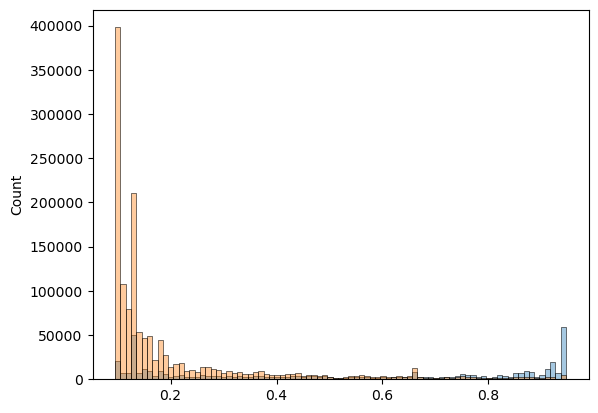

In [ ]:
# ну и посмотрим, что достаточно смешанно получается для маленьких вероятностей - нужно улучшать

mask = valid_data['target'] == 1
sns.histplot(y_pred[mask, 1], binwidth = 0.01, alpha = 0.4)
sns.histplot(y_pred[-mask, 1], binwidth = 0.01, alpha = 0.4)


## **добавим деньги - 0.818**

**фичи c прошлого раза**
-   total_actions	
-   from_last_order	
-   total_search
-   last_month_orders
-   total_orders		
-   last_month_actions		

**фичи, включающие деньги**
-   total_order_sum
-   total_order_sum_discount
-   total_cart_sum
-   total_cart_sum_discount
-   num_fav_products

In [189]:
# генерация фичей

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    actions_history = actions_history.merge(product_info, on = ['product_id'], how = 'left')

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        result = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')


    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ----- add price features -------
    # total orders
    agg = actions_history[actions_history['order']].groupby('user_id').price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum']
    result = result.merge(agg, on='user_id', how='left')

    # total order with discount
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').price.sum().reset_index()
    agg.columns = ['user_id', 'total_cart_sum']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart with discount
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_cart_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total products added added to fav 
    agg = actions_history[actions_history['action_type_id'] == 2].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'number_of_fav']
    result = result.merge(agg, on='user_id', how='left')

    return result

        
    

In [ ]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, True)
valid_data = get_features(7, True)
test_data = get_features(8, full_actions_history, full_search_history, False)

In [193]:
# модель для проверки
from sklearn.metrics import roc_auc_score
model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8231
ROC-AUC test: 0.8185


In [ ]:
test_data = get_features(8, False)

# модель для проверки
from sklearn.metrics import roc_auc_score
answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred = answer_model.predict_proba(test_data)

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm3_money.csv', index=False) 


### **выводы про деньги**




проверим, решила ли модель, что деньги важны )
![shap graph](money_shap.png)


отлично! правда `total_cart_sum` и `total_order_sum` довольно неюзабельные. сейчас посмотрим, может они со скидочной ценой скоррелированы


In [ ]:
test_data[['total_cart_sum', 'total_cart_sum_discount', 'total_orders_sum', 'total_orders_sum_discount']].dropna().corr()

,total_cart_sum,total_cart_sum_discount,total_orders_sum,total_orders_sum_discount
total_cart_sum,1.000000,0.986396,0.536529,0.519706
total_cart_sum_discount,0.986396,1.000000,0.585050,0.583357
total_orders_sum,0.536529,0.585050,1.000000,0.984681
total_orders_sum_discount,0.519706,0.583357,0.984681,1.000000


оооо да, мы видим, что эти штуки оч скоррелированы :) между друг другом конечно тоюе прилично, но все таки 0.5 далеко не 0.985

поэтому я выкидываю цену без скидки!

## **разные действия => разные последствия - 0.818**

**фичи c прошлого раза**
-   total_actions	
-   from_last_order	
-   total_search
-   last_month_orders
-   total_orders		
-   last_month_actions		

**фичи, включающие деньги**
-   total_order_sum_discount
-   total_cart_sum_discount

**фичи об отдельных `action_types`**
для каждого из них (кроме `search (4)`), с ними дальше
-   total_{`action`}_sum_discount
-   total_{`action`}

In [254]:
# генерация фичей

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    actions_history = actions_history.merge(product_info, on = ['product_id'], how = 'left')

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        result = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')


    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ----- add price features -------

    # total order with discount
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')


    # ----- different actions (just the same as for order)-----

    for act_id, act_name in [(1, 'click'), (2, 'favorite'), (5, 'cart'), (6, 'view')]:
        agg = actions_history[actions_history['action_type_id'] == act_id].groupby('user_id').size().reset_index()
        agg.columns = ['user_id', f'total_{act_name}']
        result = result.merge(agg, on='user_id', how='left')
        
        agg = actions_history[actions_history['action_type_id'] == act_id].groupby('user_id')['discount_price'].sum().reset_index()
        agg.columns = ['user_id', f'total_{act_name}_sum_discount']
        result = result.merge(agg, on='user_id', how='left')

    return result

        
    

In [255]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, True)
valid_data = get_features(7, True)
# test_data = get_features(8, full_actions_history, full_search_history, False)

In [256]:
# модель для проверки
from sklearn.metrics import roc_auc_score
model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8237
ROC-AUC test: 0.8190


In [257]:
test_data = get_features(8, False)

# модель для проверки
from sklearn.metrics import roc_auc_score
answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred = answer_model.predict_proba(test_data)

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm4_actions.csv', index=False) 


In [258]:
model.booster_.save_model('curr_model.lgb')
valid_data.to_csv('curr_val.csv', index = False)

### **выводы с разделения actions**


в названии части показано, что разделение actions вообще не повлияло на качество. 
shap это подтверждает: модель на них забила, они последние по важности, по картинке видим, что они не разделяются по значениям
![shap graph](actions_shap.png)


их все можно выкинуть


## **разнообразие товаров - 0.818**

**фичи c прошлого раза**
-   total_actions	
-   from_last_order	
-   total_search
-   last_month_orders
-   total_orders		
-   last_month_actions		

**фичи, включающие деньги**
-   total_order_sum_discount
-   total_cart_sum_discount

**подумаем о товарах**
-   total_cat_in_order
-   total_cat_in_cart
-   total_type_in_cart
-   total_types_in_order

In [265]:
# генерация фичей

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    actions_history = actions_history.merge(product_info, on = ['product_id'], how = 'left')

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        result = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')


    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ----- add price features -------

    # total was added in cart with discount
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total order with discount
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_cat_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total categories in cart
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id')['category_id'].nunique().reset_index()
    agg.columns = ['user_id', 'total_cat_in_cart']
    result = result.merge(agg, on='user_id', how='left')

    # total categories bought
    agg = actions_history[actions_history['order']].groupby('user_id')['category_id'].nunique().reset_index()
    agg.columns = ['user_id', 'total_cat_in_order']
    result = result.merge(agg, on='user_id', how='left')

    # total types in cart
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id')['type'].nunique().reset_index()
    agg.columns = ['user_id', 'total_types_in_cart']
    result = result.merge(agg, on='user_id', how='left')

    # total types bought
    agg = actions_history[actions_history['order']].groupby('user_id')['type'].nunique().reset_index()
    agg.columns = ['user_id', 'total_types_in_order']
    result = result.merge(agg, on='user_id', how='left')


    return result
    

In [266]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, True)
valid_data = get_features(7, True)
# test_data = get_features(8, full_actions_history, full_search_history, False)

In [267]:
# модель для проверки
from sklearn.metrics import roc_auc_score
model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8232
ROC-AUC test: 0.8187


In [268]:
test_data = get_features(8, False)

# модель для проверки
from sklearn.metrics import roc_auc_score
answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=50,
            subsample=0.8, 
            colsample_bytree=0.8,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            verbose = 0
        )


answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred = answer_model.predict_proba(test_data)

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm5_product_variation.csv', index=False) 


In [264]:
model.booster_.save_model('curr_model.lgb')
valid_data.to_csv('curr_val.csv', index = False)

## **побит baseline2 - 0.82120**

нашла ошибку в генерации `train` и `valid` датасетов
после исправления ручная вставка нулей на отсутствующих пользователей ухудшает качество (ура)


так как ошибка была обнаружена не сразу, данный код содержит еще просто кучу всяких новых фичей в попытке побить бейзлайн. ниже это все будет исправлено, но для честности сохраняю код сабмишена

In [ ]:
# генерация фичей
import numpy as np

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    actions_history = actions_history.merge(product_info, on = ['product_id'], how = 'left')

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        target = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        result = result.merge(target, on='user_id', how='left')
        result['target'] = result['target'].fillna(0)
        
        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')

    actions_history['some_help'] = actions_history['day'] + actions_history['month']*100

    # count days when client made orders
    agg = actions_history[actions_history['order']].groupby('user_id').some_help.nunique().reset_index()
    agg.columns = ['user_id', 'total_days_ordered']
    result = result.merge(agg, on='user_id', how='left')

    # count days when the client was active
    agg = actions_history.groupby('user_id').some_help.nunique().reset_index()
    agg.columns = ['user_id', 'total_days_active']
    result = result.merge(agg, on='user_id', how='left')

    result['order_rate'] = result['total_days_ordered'] / result['total_days_active']

    # сount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # сount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].min()).reset_index()
    diff.columns = ['user_id', 'from_first_order']  
    diff['from_first_order'] = diff['from_first_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')


    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ----- add price features -------
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.max().reset_index()
    agg.columns = ['user_id', 'max_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total order with discount
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.max().reset_index()
    agg.columns = ['user_id', 'max_cart_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart with discount
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_cart_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total products added added to fav 
    agg = actions_history[actions_history['action_type_id'] == 2].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'number_of_fav']
    result = result.merge(agg, on='user_id', how='left')

    agg = actions_history[actions_history['action_type_id'] == 1].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'number_of_clicks']
    result = result.merge(agg, on='user_id', how='left')

    result['log_total_cart'] = np.log1p(result['total_cart_sum_discount'])
    result['log_total_order'] = np.log1p(result['total_orders_sum_discount'])

    # действия 2 месяца назад
    m2 = actions_history[actions_history['month'] == thr_month-2] \
    .groupby('user_id').size().reset_index(name='actions_m2')

# действия 1 месяц назад    
    m1 = actions_history[actions_history['month'] == thr_month-1] \
    .groupby('user_id').size().reset_index(name='actions_m1')

    trend = m1.merge(m2, on='user_id', how='left')
    trend['actions_trend'] = trend['actions_m1'] - trend['actions_m2']

    result = result.merge(trend[['user_id', 'actions_trend']], on='user_id', how='left')

    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - 
        actions_history.groupby('user_id')['timestamp'].max()).reset_index()

    diff.columns = ['user_id', 'from_last_action']
    diff['from_last_action'] = diff['from_last_action'].dt.days

    result = result.merge(diff, on='user_id', how='left')

    result['orders_per_action'] = result['total_orders'] / result['total_actions']
    result['orders_per_search'] = result['total_orders'] / result['total_search']

    result['actions_per_day'] = result['total_actions'] / result['total_days_active']
    result['orders_per_day'] = result['total_orders'] / result['total_days_active']

    actions_history['days_ago'] = (
    pd.Timestamp(f'2024-0{thr_month}-01') - actions_history['timestamp']
    ).dt.days

    actions_history['weight'] = np.exp(-actions_history['days_ago'] / 30)   

    agg = actions_history.groupby('user_id')['weight'].sum().reset_index()
    agg.columns = ['user_id', 'weighted_actions']
    result = result.merge(agg, on='user_id', how='left')


    search_history['days_ago'] = (
        pd.Timestamp(f'2024-0{thr_month}-01') - search_history['timestamp']
        ).dt.days

    result['is_alive'] = (result['from_last_action'] < 14).astype(int)

    agg = search_history[search_history['days_ago'] < 7] \
        .groupby('user_id').size().reset_index(name='search_last_7')
    result = result.merge(agg, on='user_id', how='left')

    result['cart_to_order'] = result['last_month_orders'] / result['last_month_actions']


    m2 = actions_history[(actions_history['month'] == thr_month-2) & (actions_history['order'])] \
    .groupby('user_id').size().reset_index(name='orders_m2')

    m1 = actions_history[(actions_history['month'] == thr_month-1) & (actions_history['order'])] \
    .groupby('user_id').size().reset_index(name='orders_m1')

    trend = m1.merge(m2, on='user_id', how='left')
    trend['orders_trend'] = trend['orders_m1'] / (trend['orders_m2'] + 1)

    result = result.merge(trend[['user_id', 'orders_trend']], on='user_id', how='left')

    return result


In [64]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, True)
valid_data = get_features(7, True)
test_data = get_features(8,  False)

In [73]:
# модель для проверки
from sklearn.metrics import roc_auc_score

model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            eta = 0.05, 
            max_leaves = 70, 
            linear_lambda = 0.5,
            scale_pos_weight = 3,
            n_estimators = 300,
        )

model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8369
ROC-AUC test: 0.8283


In [69]:
from sklearn.metrics import roc_auc_score
answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            eta = 0.05, 
            max_leaves = 70, 
            linear_lambda = 0.5,
            scale_pos_weight = 3,
            n_estimators = 200,
            verbose = -1
        )

answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred_tr = answer_model.predict_proba(valid_data.drop('target', axis = 1))
train_auc = roc_auc_score(valid_data['target'], y_pred_tr[:, 1])
print(f'\tROC-AUC train: {train_auc:.4f}')

y_pred = answer_model.predict_proba(test_data.drop('pred', axis = 1))

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
print(y_pred[~mask, 1])
#y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm12_improved.csv', index=False) 


	ROC-AUC train: 0.8406
[0.13564253 0.13564253 0.12471531 ... 0.1344342  0.13447975 0.13597411]


<Axes: ylabel='Count'>

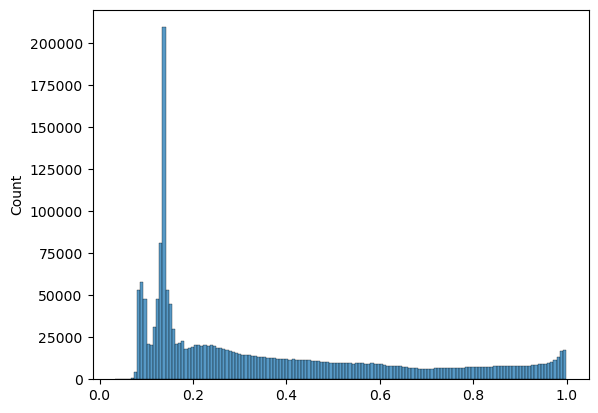

In [ ]:
sns.histplot(y_pred[:, 1])

# мы сейчас видим, что модель предсказывает 0.13 для людей, которые никогда не заходили на сайт

# заменить их на 0 не совсем верно, но в прошлые разы это спасало, 
# НО там было неверная генерация датафреймов
# если я правильно понимаю, то сейчас перенос всех в 0 должен ухудшить результат

In [ ]:
# теперь такое действие ухудшает качество на 0.003, а не повышает 
# значит, теперь все корректно работает в модели 

y_pred = answer_model.predict_proba(test_data.drop('pred', axis = 1))

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm13_improved_manual0.csv', index=False) 

## **убираем лишние фичи с последнего сабмита - 0.82052**

посмотрела с помощью SHAP графика с дз3: какие фичи важны, а какие - нет.

![shap graph](remove_shit.png)

**оставленные фичи, на которых построим адекватное решение**

**фичи c первого раза**
-   total_actions  
-   from_last_order  
-   total_search
-   last_month_orders
-   total_orders  
-   from_last_action  

**фичи, включающие деньги**
-   total_order_sum_discount
-   total_cart_sum_discount

**из ново добавленных**
-   total_days_active
-   search_last_7
-   orders_per_search
-   orders_per_action
-   weighted_actions
-   actions_per_day
-   total_days_ordered


In [10]:
# обучимся на них, подберем корректные параметры модели

# генерация фичей
import numpy as np

def get_features(thr_month, make_y = True):
    # clip by month
    actions_history = full_actions_history.copy()
    search_history = full_search_history.copy()
    actions_history['month'] = actions_history['timestamp'].dt.month

    actions_history = actions_history.merge(product_info, on = ['product_id'], how = 'left')

    result = test_users.copy()

    if make_y:
        # make target
        actions_history['month_order'] = (actions_history['order'] == True) & (actions_history['month'] == thr_month)

        target = (
            actions_history.groupby('user_id')['month_order']
            .any()
            .astype(int)
            .reset_index(name='target')
        )

        result = result.merge(target, on='user_id', how='left')
        result['target'] = result['target'].fillna(0)
        
        actions_history = actions_history.drop('month_order', axis = 1)
        actions_history = actions_history[actions_history['month'] < thr_month]
        search_history = search_history[search_history['month'] < thr_month]
    
    # count total orders
    agg = actions_history.groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'total_orders']
    result = result.merge(agg, on='user_id', how='left')

    actions_history['some_help'] = actions_history['day'] + actions_history['month']*100

    # count days when client made orders
    agg = actions_history[actions_history['order']].groupby('user_id').some_help.nunique().reset_index()
    agg.columns = ['user_id', 'total_days_ordered']
    result = result.merge(agg, on='user_id', how='left')

    # count days when the client was active
    agg = actions_history.groupby('user_id').some_help.nunique().reset_index()
    agg.columns = ['user_id', 'total_days_active']
    result = result.merge(agg, on='user_id', how='left')

    # сount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].max()).reset_index()
    diff.columns = ['user_id', 'from_last_order']  
    diff['from_last_order'] = diff['from_last_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # сount days from last order
    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - actions_history[actions_history['order']].groupby('user_id')['timestamp'].min()).reset_index()
    diff.columns = ['user_id', 'from_first_order']  
    diff['from_first_order'] = diff['from_first_order'].dt.days
    result = result.merge(diff, on='user_id', how='left')

    # actions за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'last_month_actions']
    result = result.merge(agg, on='user_id', how='left')

    # actions за все время
    agg = actions_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_actions']
    result = result.merge(agg, on='user_id', how='left')

    # search за все время
    agg = search_history.groupby('user_id').size().reset_index()
    agg.columns = ['user_id', 'total_search']
    result = result.merge(agg, on='user_id', how='left')

    # количество покупок за последний месяц
    agg = actions_history[(actions_history['month'] == thr_month-1)].groupby('user_id')['order'].sum().reset_index()
    agg.columns = ['user_id', 'last_month_orders']
    result = result.merge(agg, on='user_id', how='left')


    # ----- add price features -------

    # total order with discount
    agg = actions_history[actions_history['order']].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_orders_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.max().reset_index()
    agg.columns = ['user_id', 'max_cart_sum_discount']
    result = result.merge(agg, on='user_id', how='left')

    # total in cart with discount
    agg = actions_history[actions_history['action_type_id'] == 5].groupby('user_id').discount_price.sum().reset_index()
    agg.columns = ['user_id', 'total_cart_sum_discount']
    result = result.merge(agg, on='user_id', how='left')


    diff = (pd.Timestamp(f'2024-0{thr_month}-01') - 
        actions_history.groupby('user_id')['timestamp'].max()).reset_index()

    diff.columns = ['user_id', 'from_last_action']
    diff['from_last_action'] = diff['from_last_action'].dt.days

    result = result.merge(diff, on='user_id', how='left')

    result['orders_per_action'] = result['total_orders'] / result['total_actions']
    result['orders_per_search'] = result['total_orders'] / result['total_search']
    result['actions_per_day'] = result['total_actions'] / result['total_days_active']

    actions_history['days_ago'] = (
    pd.Timestamp(f'2024-0{thr_month}-01') - actions_history['timestamp']
    ).dt.days

    actions_history['weight'] = np.exp(-actions_history['days_ago'] / 30)   
    agg = actions_history.groupby('user_id')['weight'].sum().reset_index()
    agg.columns = ['user_id', 'weighted_actions']
    result = result.merge(agg, on='user_id', how='left')

    search_history['days_ago'] = (
        pd.Timestamp(f'2024-0{thr_month}-01') - search_history['timestamp']
        ).dt.days

    agg = search_history[search_history['days_ago'] < 7] \
        .groupby('user_id').size().reset_index(name='search_last_7')
    result = result.merge(agg, on='user_id', how='left')

    return result


In [11]:
# train_data - target is june (6)
# valid_data - target is july (7)
# test_data - features via full dataset (including july)

train_data = get_features(6, True)
valid_data = get_features(7, True)
test_data = get_features(8,  False)

In [12]:
# модель для проверки
from sklearn.metrics import roc_auc_score

model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            max_leaves = 70, 
            scale_pos_weight = 3,
            n_estimators = 300,
            verbose = -1
        )

model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')


ROC-AUC train: 0.8365
ROC-AUC test: 0.8277


In [14]:
from sklearn.metrics import roc_auc_score

answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            max_leaves = 70, 
            scale_pos_weight = 3,
            n_estimators = 300,
            verbose = -1
        )

answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred_tr = answer_model.predict_proba(valid_data.drop('target', axis = 1))
train_auc = roc_auc_score(valid_data['target'], y_pred_tr[:, 1])
print(f'\tROC-AUC train: {train_auc:.4f}')

y_pred = answer_model.predict_proba(test_data)

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
print(y_pred[~mask, 1])
#y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm14_no_trash.csv', index=False) 


	ROC-AUC train: 0.8414
[0.14012151 0.14012151 0.13911593 ... 0.13277937 0.1324556  0.13244871]


**нормалды**
качество такое же, значит все ненужное просто выкинули из модели

давайте перебирать параметры

## **параметры модели - 0.82063**

в LightGBM разрешается перебирать только параметры `learning_rate`, `num_leaves`, `lambda_l2` (если юзаете GBDT_PL)

In [48]:
lrates = [0.05, 0.1, 0.2]
leaves = [15, 31, 63, 127, 200, 500]
l2s = [0, 0.1, 0.5]

train_rocaucs = []
test_rocaucs = []

matrix = [[0 for _ in range( len(leaves) * len(lrates) * len(l2s))] for p in range(len(lrates) + len(leaves) + len(l2s))]
idx = 0

for i, leavenum in enumerate(leaves):
    for j, lrate in enumerate(lrates):
        for k, l2 in enumerate(l2s):
            model = lgb.LGBMClassifier(
                objective='binary',
                boosting_type='gbdt',
                num_leaves = leavenum, 
                learning_rate = lrate,
                reg_lambda = l2,
                scale_pos_weight = 3,
                n_estimators = 300,
                verbose = 0
                )

            model.fit(train_data.drop('target', axis = 1), train_data['target'])

            y_pred = model.predict_proba(train_data.drop('target', axis = 1))
            train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

            y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
            test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

            train_rocaucs.append(train_auc)
            test_rocaucs.append(test_auc)

            matrix[i][idx] = 1                     
            matrix[len(leaves) + j][idx] = 1      
            matrix[len(leaves) + len(lrates) + k][idx] = 1  

            idx += 1



Text(1.05, 5, '')

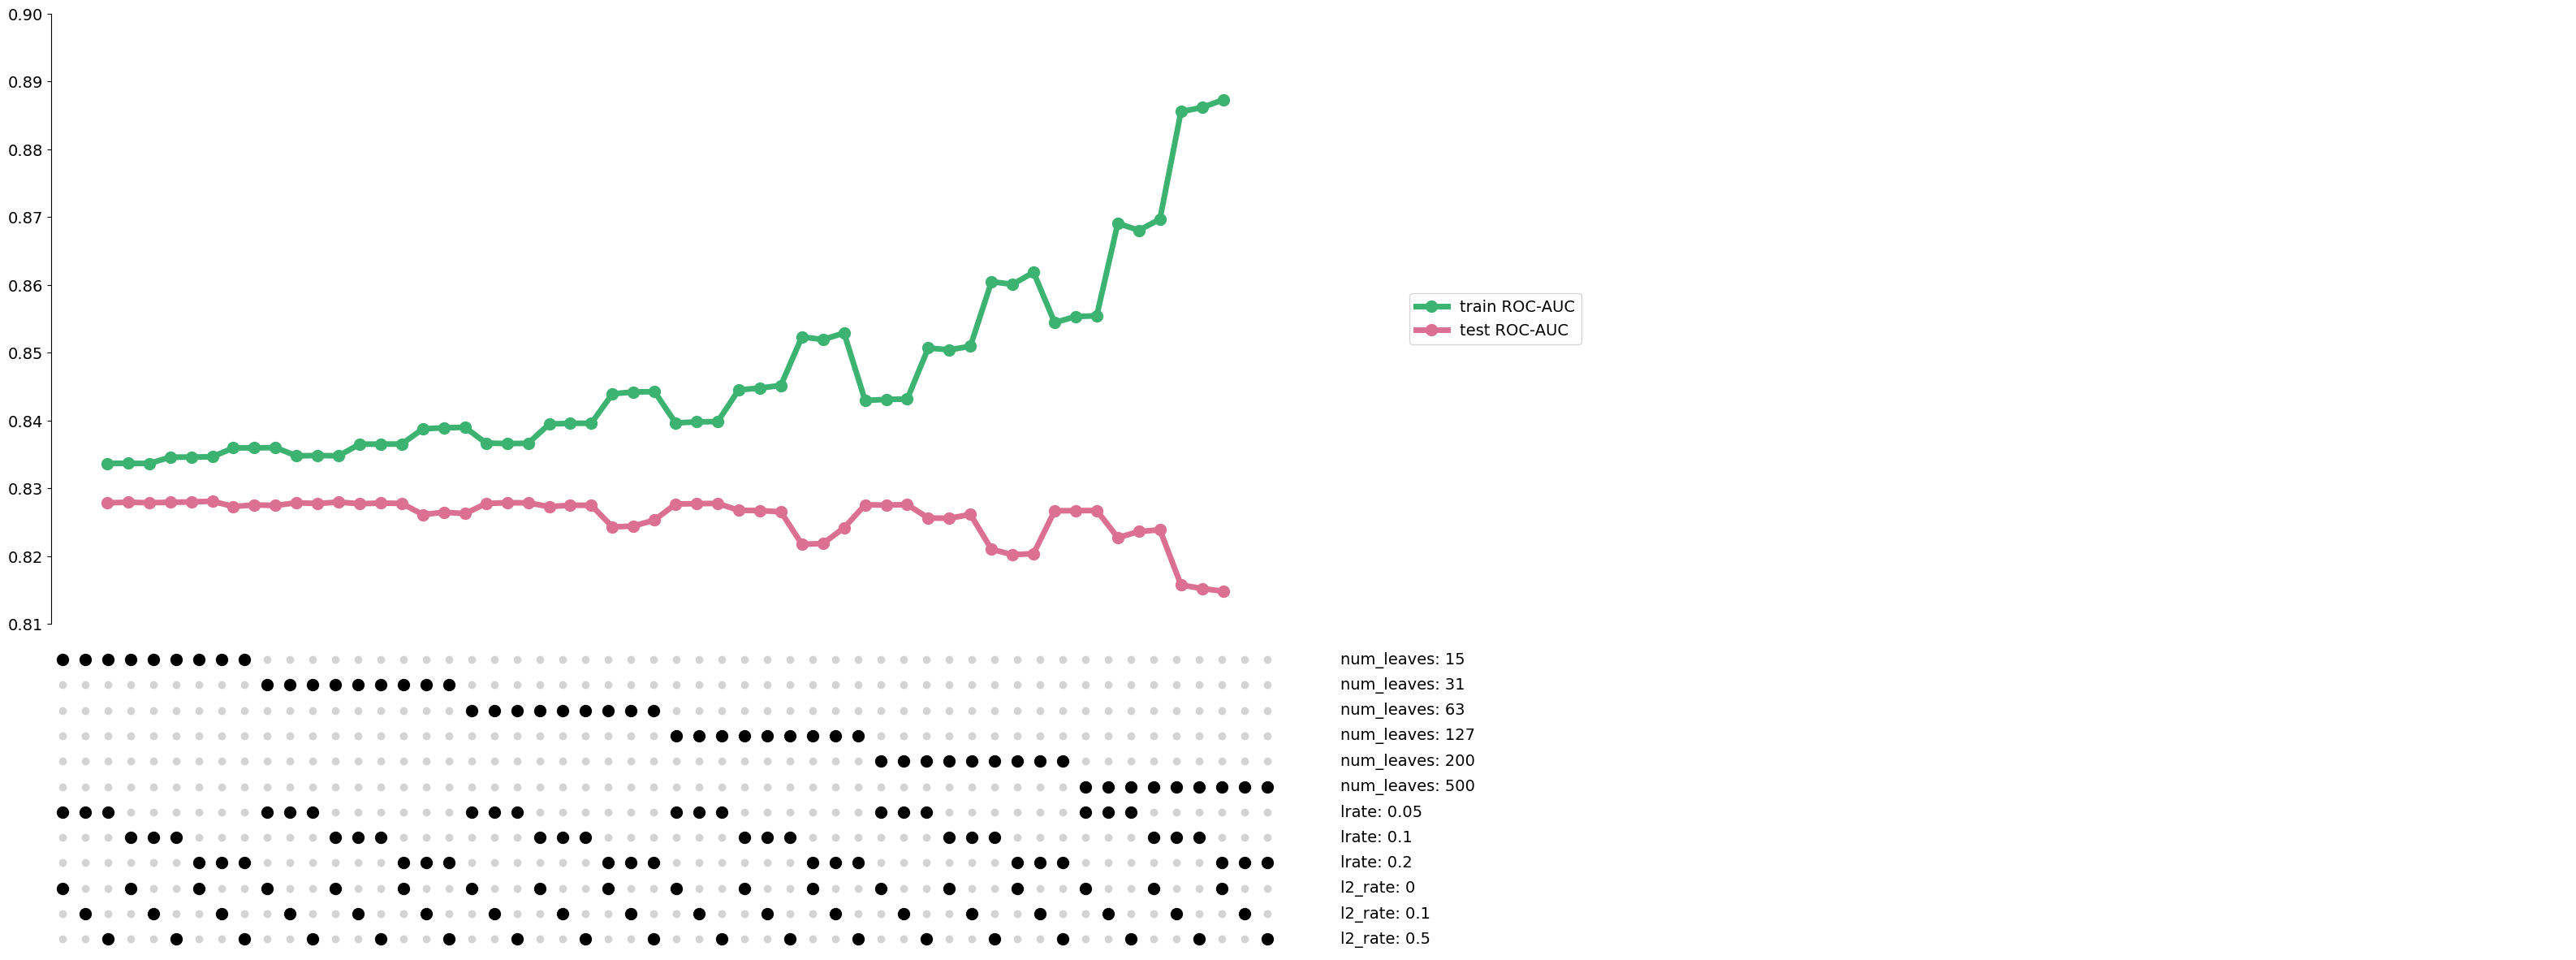

In [62]:
from matplotlib.gridspec import GridSpec

matrix = np.array(matrix)

n_models = len(lrates) * len(leaves) * len(l2s)
x = np.arange(n_models)

rows = [f'num_leaves: {x}' for x in leaves] + [f'lrate: {x}' for x in lrates] + [f'l2_rate: {x}' for x in l2s]

matrix = matrix.T

fig = plt.figure(figsize=(40, 15))
gs = GridSpec(
    2, 2,
    height_ratios=[4, 2],
    width_ratios=[2, 2],
    hspace=0.05,
    wspace=0.05
)

ax_top    = fig.add_subplot(gs[0, 0])
ax_matrix = fig.add_subplot(gs[1, 0])
ax_labels = fig.add_subplot(gs[1, 1])


ax_top.plot(x, train_rocaucs, marker="o", lw=5, markersize = 10, color = "mediumseagreen", label = 'train ROC-AUC')
ax_top.plot(x, test_rocaucs,  marker="o", lw=5,  markersize = 10, color = "palevioletred", label = 'test ROC-AUC')

# Для соединения точек линиями (без маркеров)
ax_top.plot(x, train_rocaucs, lw=2, color="mediumseagreen", zorder=2)
ax_top.plot(x, test_rocaucs, lw=2, color="palevioletred", zorder=2)

ax_top.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize = 14)


ax_top.set_ylim(0.81, 0.9)
ax_top.set_xticks([])
ax_top.tick_params(axis='y', labelsize=14)
ax_top.spines[['right', 'top', 'bottom']].set_visible(False)

ax_matrix.set_xlim(-0.5, n_models - 0.5)
ax_matrix.set_ylim(-0.5, len(rows) - 0.5)

for i in range(len(rows)):
    for j in range(n_models):
        if matrix[i, j]:
            ax_matrix.plot(j, i, 'o', color='black', markersize = 10)
        else:
            ax_matrix.plot(j, i, 'o', color='lightgrey')


ax_matrix.invert_yaxis()
ax_matrix.axis('off')

ax_labels.set_ylim(ax_matrix.get_ylim())
ax_labels.axis('off')

for i, label in enumerate(rows):
    ax_labels.text(0, i, label, va='center', fontsize=14)


ax_labels.text(
    1.05, 1.5,
    "",
    fontsize=12,
    weight='bold'
)

ax_labels.text(
    1.05, 5,
    "",
    fontsize=12,
    weight='bold'
)


в принципе этот график отражает суть

1.  `num_leaves`: как только переваливается за 100, начинаем видеть жесткое переобучение. 
2.  `learning_rate`: не очень сильно роляет, если небольшое количество листов. но `0.1` уже большеват) `0.05` оптимально
3.  `l2_rate` (`reg_lambda`): очень минорные изменения. можно `0.05` поставить и бог с ним

**overall**, давайте обучим на `num_leaves = 31 (default)`, `learning_rate = 0.05`, `l2_rate = 0.05`

In [ ]:
# модель для проверки
from sklearn.metrics import roc_auc_score

model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            max_leaves = 70, 
            scale_pos_weight = 3,
            n_estimators = 300,
            verbose = -1,
            num_leaves = 31, 
            learning_rate = 0.05,
            reg_lambda = 0.05,
        )

model.fit(train_data.drop('target', axis = 1), train_data['target'])

y_pred = model.predict_proba(train_data.drop('target', axis = 1))
train_auc = roc_auc_score(train_data['target'], y_pred[:, 1])

y_pred = model.predict_proba(valid_data.drop('target', axis = 1))
test_auc = roc_auc_score(valid_data['target'], y_pred[:, 1])

print(f'ROC-AUC train: {train_auc:.4f}')
print(f'ROC-AUC test: {test_auc:.4f}')

# ну на самом то деле это буквально то же самое что в последнем сабмишне, раз свободные остались я сдам

# но на самом деле вообще нету смысла по новой это отправлять: получилось 0.82063


ROC-AUC train: 0.8348
ROC-AUC test: 0.8277


In [66]:
from sklearn.metrics import roc_auc_score

answer_model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            max_leaves = 70, 
            scale_pos_weight = 3,
            n_estimators = 300,
            verbose = -1,
            num_leaves = 31, 
            learning_rate = 0.05,
            reg_lambda = 0.05,
        )

answer_model.fit(valid_data.drop('target', axis = 1), valid_data['target'])

y_pred_tr = answer_model.predict_proba(valid_data.drop('target', axis = 1))
train_auc = roc_auc_score(valid_data['target'], y_pred_tr[:, 1])
print(f'\tROC-AUC train: {train_auc:.4f}')

y_pred = answer_model.predict_proba(test_data)

x = pd.read_parquet('/mnt/calc/lizzzafomenko/aim/actions_history')
mask = test_users['user_id'].isin(x['user_id'])
print(y_pred[~mask, 1])
#y_pred[~mask, 1] = 0
test_data['pred'] = y_pred[:, 1]
test_data[['user_id', 'pred']].to_csv('subm15_params.csv', index=False) 


	ROC-AUC train: 0.8397
[0.13710629 0.13710629 0.13425009 ... 0.13427673 0.13442577 0.13498637]


**микро-вывод**

подбирать параметры тут не нужно. мы видим, что дефолтная модель - лучшая, все остальное либо так же, либо хуже
интересно, что уже при 100 листьях модель переобучается.

в общем, помогут тут только крутые фичи :)

In [85]:
model.booster_.save_model('curr_model.lgb')
valid_data.to_csv('curr_val.csv', index = False)